# Imports

In [2]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Data Preprocessing ===
from sklearn.preprocessing import StandardScaler

# === Model Selection and Training ===
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# === Evaluation Metrics ===
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

Feature cleaning and definition

In [3]:
# Upload Dataset
df = pd.read_csv("final_books_for_forecasting.csv")

# Feature Preprocessing
df["Date"] = pd.to_datetime(df["Date"])
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Price"] = df["Price"].astype(str).str.replace("грн.", "").str.replace(",", ".")
df["Price"] = df["Price"].str.extract(r"(\d+\.?\d*)")[0].astype(float)
df["Pages"] = df["Pages"].astype(str).str.extract(r"(\d+)")[0].astype(float)
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["Quarter"] = df["Date"].dt.quarter
df["Is_Holiday_Season"] = df["Month"].isin([11, 12, 1]).astype(int)
df["Is_Summer"] = df["Month"].isin([6, 7, 8]).astype(int)
df = df.sort_values(["Title", "Date"]).reset_index(drop=True)
df["lag_1"] = df.groupby("Title")["Sales"].shift(1)
df["lag_2"] = df.groupby("Title")["Sales"].shift(2)
df["rolling_mean_3"] = (
    df.groupby("Title")["Sales"]
      .apply(lambda x: x.shift(1).rolling(3).mean())
      .reset_index(level=0, drop=True)
)
df["cumulative_sales"] = df.groupby("Title")["Sales"].cumsum()
df["active_months"] = df.groupby("Title")["Sales"].transform(lambda x: (x > 0).expanding().sum())
df["Sales_log"] = np.log1p(df["Sales"])
df["Covid"] = df["Year"].isin([2020, 2021]).astype(int)
df["War"] = (df["Year"] == 2022).astype(int)
df.dropna(subset=["lag_1", "lag_2", "rolling_mean_3"], inplace=True)

# Discontinued flag
def mark_discontinued(s):
    zeros = (s==0)
    # run‐length encode from the end
    run = 0
    flags = []
    for v in zeros[::-1]:
        if v:
            run += 1
        else:
            run = 0
        flags.append(run>=6)
    return pd.Series(flags[::-1], index=s.index)

df["Discontinued"] = df.groupby("Title")["Sales"].apply(mark_discontinued).reset_index(0,drop=True).astype(int)

features = [
    "lag_1", "lag_2", "rolling_mean_3", "cumulative_sales", "active_months",
    "Author Score", "Price", "Pages", "Month", "Year", "Quarter",
    "Is_Holiday_Season", "Is_Summer", "Discontinued", "Covid", "War", "Is_Active_Period"
]

Train/Validation/Test Split

In [4]:
# Split by Title (shuffled)
titles = df["Title"].unique()

# Save 160 titles for validation+test
train_titles, temp_titles = train_test_split(
    titles,
    test_size=160,
    random_state=42,
    shuffle=True
)

# Split 160 titles into val/test
val_titles, test_titles = train_test_split(
    temp_titles,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

# Create Datasets
train_df = df[df["Title"].isin(train_titles)].copy()
val_df   = df[df["Title"].isin(val_titles)].copy()
test_df  = df[df["Title"].isin(test_titles)].copy()

# Scale train/val/test
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[features])
X_val   = scaler.transform(val_df[features])
X_test  = scaler.transform(test_df[features])

y_train = train_df["Sales_log"].values
y_val   = val_df["Sales_log"].values
y_test  = test_df["Sales_log"].values

Train Linear Regression/Random Forest/MLP and Evaluations

In [5]:
# Train Models
results = []
actual_sales = np.expm1(y_test)         # back‐transform
predictions_df = test_df[["Title","Date"]].copy()
predictions_df["Actual_Sales"] = actual_sales

models = {
    "Linear_Regression":  LinearRegression(),
    "Random_Forest":      RandomForestRegressor(n_estimators=300, random_state=42),
    "MLP_Neural_Net":     MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
}

# replace any NaNs before fitting
X_train_np = np.nan_to_num(X_train, nan=0.0)
X_test_np  = np.nan_to_num(X_test,  nan=0.0)

for name, model in models.items():
    # train
    model.fit(X_train_np, y_train)
    # predict & back‐transform
    pred_sales = np.expm1(model.predict(X_test_np))

    # evaluation metrics
    mae = mean_absolute_error(actual_sales, pred_sales)
    rmse = np.sqrt(mean_squared_error(actual_sales, pred_sales))
    r2 = r2_score(actual_sales, pred_sales)
    mae_range = mae / (actual_sales.max() - actual_sales.min())

    # save results
    predictions_df[name] = pred_sales
    results.append({
        "Model":      name,
        "MAE":        mae,
        "RMSE":       rmse,
        "R2":         r2,
        "MAE/Range":  mae_range
    })

In [6]:
# Save results
results_df = pd.DataFrame(results)
predictions_df.to_csv("all_model_predictions.csv", index=False)
results_df.to_csv("all_model_results.csv", index=False)

Define ranges and calculate MAE per Sales Range

In [9]:
# Load predictions
df = pd.read_csv("all_model_predictions.csv")

# Define ranges & labels
custom_ranges = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90,
               100, 120, 140, 160, 180, 200, 225, 250,
               300, 350, 400, 430, 450, 500, 600, 700, 800]
labels = [f"{custom_ranges[i]}–{custom_ranges[i+1]}"
          for i in range(len(custom_ranges) - 1)]

df["Sales_Range"] = pd.cut(
    df["Actual_Sales"],
    bins=custom_ranges,
    labels=labels,
    include_lowest=True,
    right=False
)

model_columns = [
    "Linear_Regression",
    "Random_Forest",
    "MLP_Neural_Net",
]

# Compute MAE & MAE/Range per range & model
def compute_metrics(sub: pd.DataFrame):
    ranges = sub["Actual_Sales"].max() - sub["Actual_Sales"].min()
    rows = []
    for m in model_columns:
        mae = (sub[m] - sub["Actual_Sales"]).abs().mean()
        mae_range = mae / ranges if ranges > 0 else np.nan
        rows.append({
            "Model":      m,
            "MAE":        mae,
            "Range":      ranges,
            "MAE/Range":  mae_range
        })
    return pd.DataFrame(rows)

# Apply per range
mae_range_df = (
    df
    .groupby("Sales_Range", observed=True)
    .apply(compute_metrics)
    .reset_index(level=0)
    .rename_axis(None, axis=1)
)

mae_range_df.to_csv("mae_range.csv", index=False)
print(mae_range_df)

   Sales_Range              Model         MAE  Range  MAE/Range
0         0–10  Linear_Regression    2.002616    9.0   0.222513
1         0–10      Random_Forest    1.632523    9.0   0.181391
2         0–10     MLP_Neural_Net    1.714925    9.0   0.190547
0        10–20  Linear_Regression    8.677856    9.0   0.964206
1        10–20      Random_Forest    8.906533    9.0   0.989615
..         ...                ...         ...    ...        ...
1      600–700      Random_Forest  405.795584    0.0        NaN
2      600–700     MLP_Neural_Net  657.005235    0.0        NaN
0      700–800  Linear_Regression  678.273758   10.0  67.827376
1      700–800      Random_Forest  332.845105   10.0  33.284510
2      700–800     MLP_Neural_Net  424.551269   10.0  42.455127

[78 rows x 5 columns]


<ipython-input-9-273ce9ecc87b>:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_metrics)


# Results Visualizations

MAE per Sales Range distribution

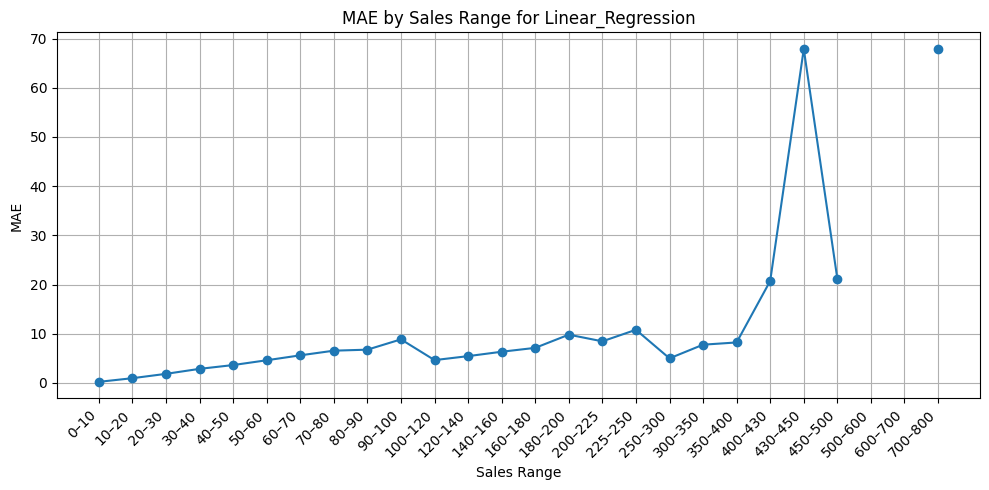

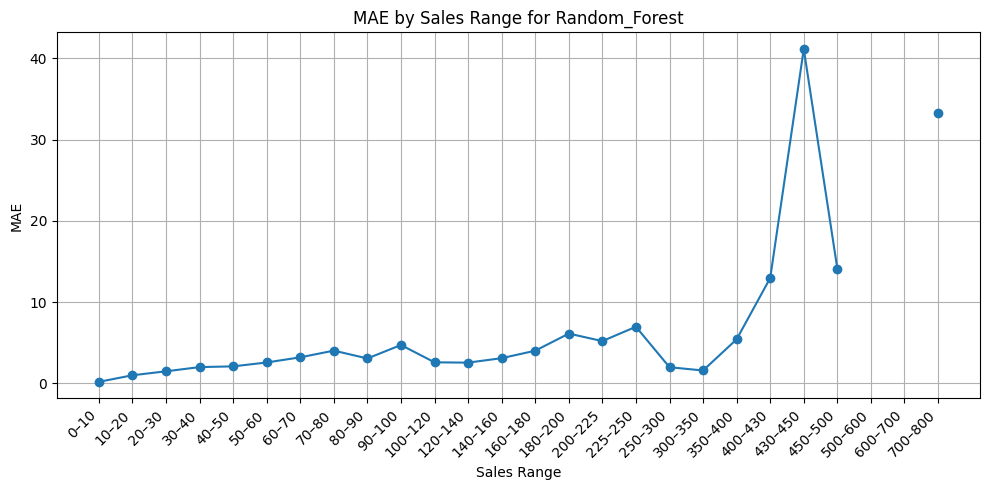

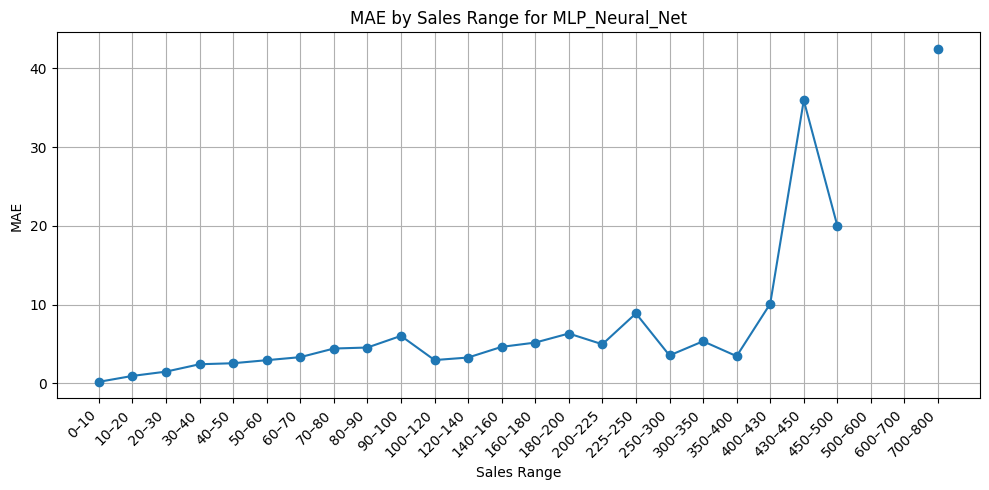

In [10]:
# Define Models
models = ["Linear_Regression", "Random_Forest", "MLP_Neural_Net"]

# Plot
for model in models:
    subset = mae_range_df[mae_range_df["Model"] == model]
    plt.figure(figsize=(10, 5))
    plt.plot(subset["Sales_Range"], subset["MAE/Range"], marker='o', label=model)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Sales Range")
    plt.ylabel("MAE")
    plt.title(f"MAE by Sales Range for {model}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Sales per Sales Range distribution

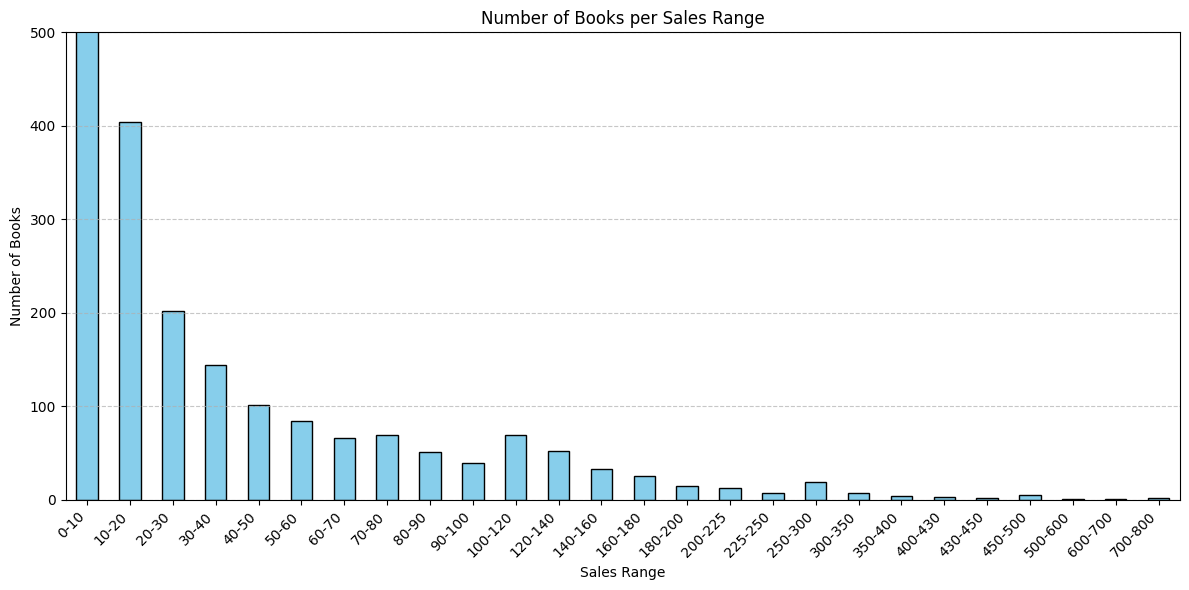

In [11]:
# Load file with predictions
predictions_df = pd.read_csv("all_model_predictions.csv")

# Define sales range and labels
sales_range = [
    (0, 10), (10, 20), (20, 30), (30, 40), (40, 50),
    (50, 60), (60, 70), (70, 80), (80, 90), (90, 100),
    (100, 120), (120, 140), (140, 160), (160, 180), (180, 200),
    (200, 225), (225, 250), (250, 300), (300, 350), (350, 400),
    (400, 430), (430, 450), (450, 500), (500, 600), (600, 700), (700, 800)
]
sales_range_labels = [
    "0-10", "10-20", "20-30", "30-40", "40-50",
    "50-60", "60-70", "70-80", "80-90", "90-100",
    "100-120", "120-140", "140-160", "160-180", "180-200",
    "200-225", "225-250", "250-300", "300-350", "350-400",
    "400-430", "430-450", "450-500", "500-600", "600-700", "700-800"
]

# Assign sales ranges
def assign_sales_range(sales):
    for (low, high), label in zip(sales_range, sales_range_labels):
        if low <= sales < high:
            return label
    return None

predictions_df["Sales_Range"] = predictions_df["Actual_Sales"].apply(assign_sales_range)

# Count books per range
sales_range_counts = predictions_df["Sales_Range"].value_counts().reindex(sales_range_labels, fill_value=0)

# Plot
plt.figure(figsize=(12, 6))
sales_range_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Number of Books per Sales Range")
plt.xlabel("Sales Range")
plt.ylabel("Number of Books")
plt.ylim(0, 500)  # <--- LIMIT Y-AXIS
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


Feature Importance for Random Forest plot

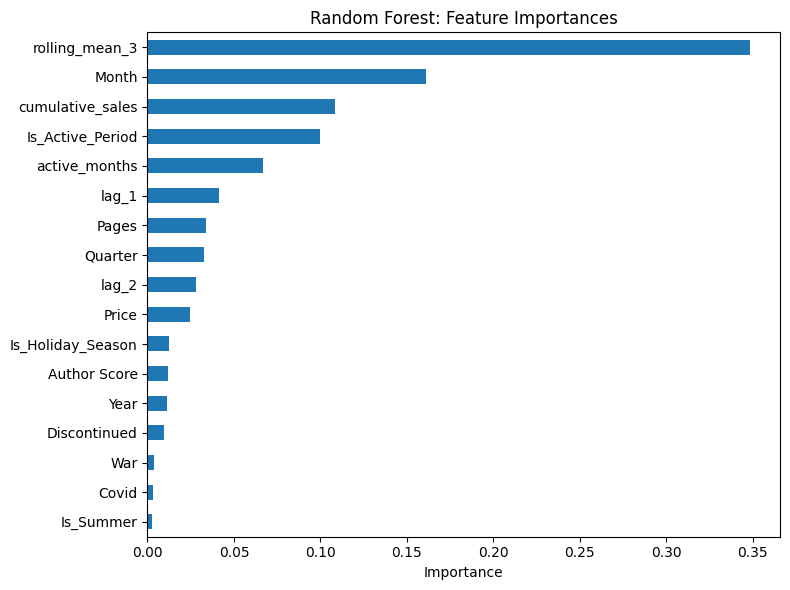

In [12]:
# Additional train of RF
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Define forecasting features
feature_names = [
    "lag_1", "lag_2", "rolling_mean_3", "cumulative_sales", "active_months",
    "Author Score", "Price", "Pages", "Month", "Year", "Quarter",
    "Is_Holiday_Season", "Is_Summer", "Discontinued", "Covid", "War", "Is_Active_Period"
]

assert len(feature_names) == rf.feature_importances_.shape[0], \
       f"Expected {rf.feature_importances_.shape[0]} names, got {len(feature_names)}"

importances = rf.feature_importances_
imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# top features plot
plt.figure(figsize=(8, 6))
imp_series.plot.barh()
plt.title("Random Forest: Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


Forecasted vs Actual Sales plot

In [13]:
def plot_forecasts_per_book(predictions_df, book_ids, models_to_show=None, holidays=None):

    # Define models
    base = {'Title','Date','Actual_Sales','Actual','Book_Title'}
    if models_to_show is None:
        models_to_show = [m for m in predictions_df.columns if m not in base]

    for book in book_ids:
        book_df = predictions_df[predictions_df['Title'] == book].copy()
        if book_df.empty:
            print(f"No data for book: {book}")
            continue

        # Ensure datetime
        book_df['Date'] = pd.to_datetime(book_df['Date'])

        book_df.sort_values('Date', inplace=True)
        fig, ax = plt.subplots(figsize=(14,6))

        ax.plot(book_df['Date'], book_df['Actual_Sales'],
                label='Actual', color='black', linewidth=2)

        # Plot each model
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        for color, model in zip(colors, models_to_show):
            if model in book_df:
                ax.plot(book_df['Date'], book_df[model],
                        linestyle='--', label=model, color=color)


        ax.set_title(f"Forecast vs Actual Sales — {book}")
        ax.set_xlabel("Date")
        ax.set_ylabel("Sales")
        ax.legend()
        ax.grid(True)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

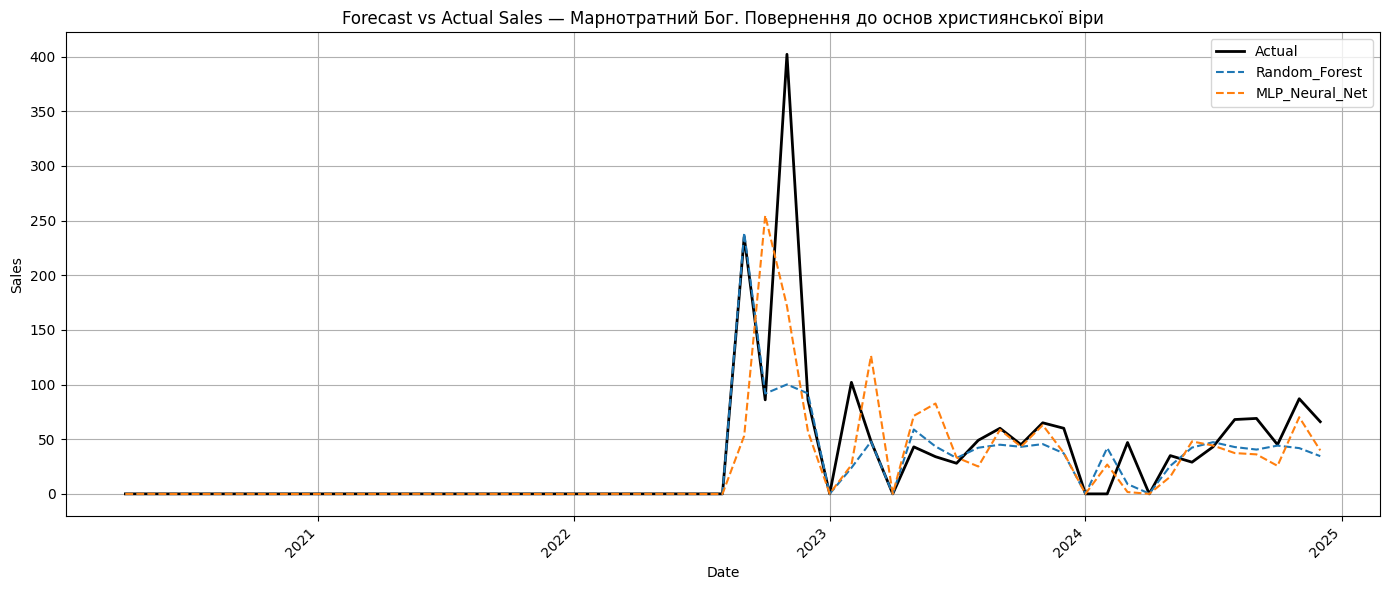

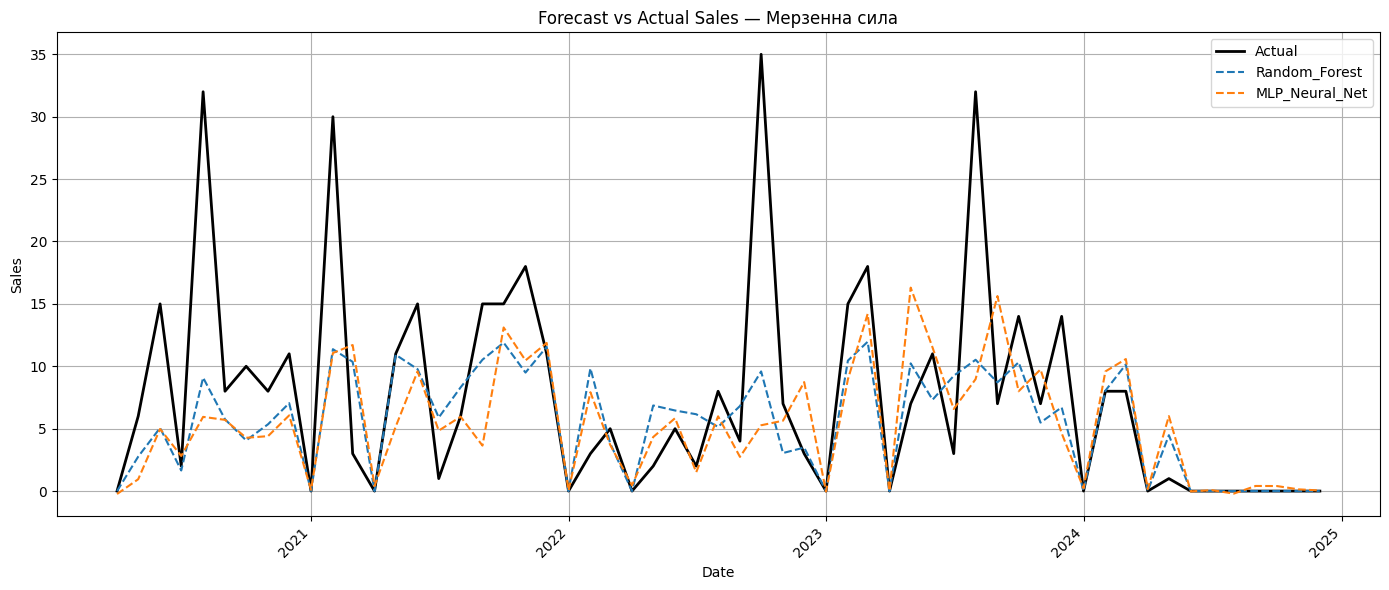

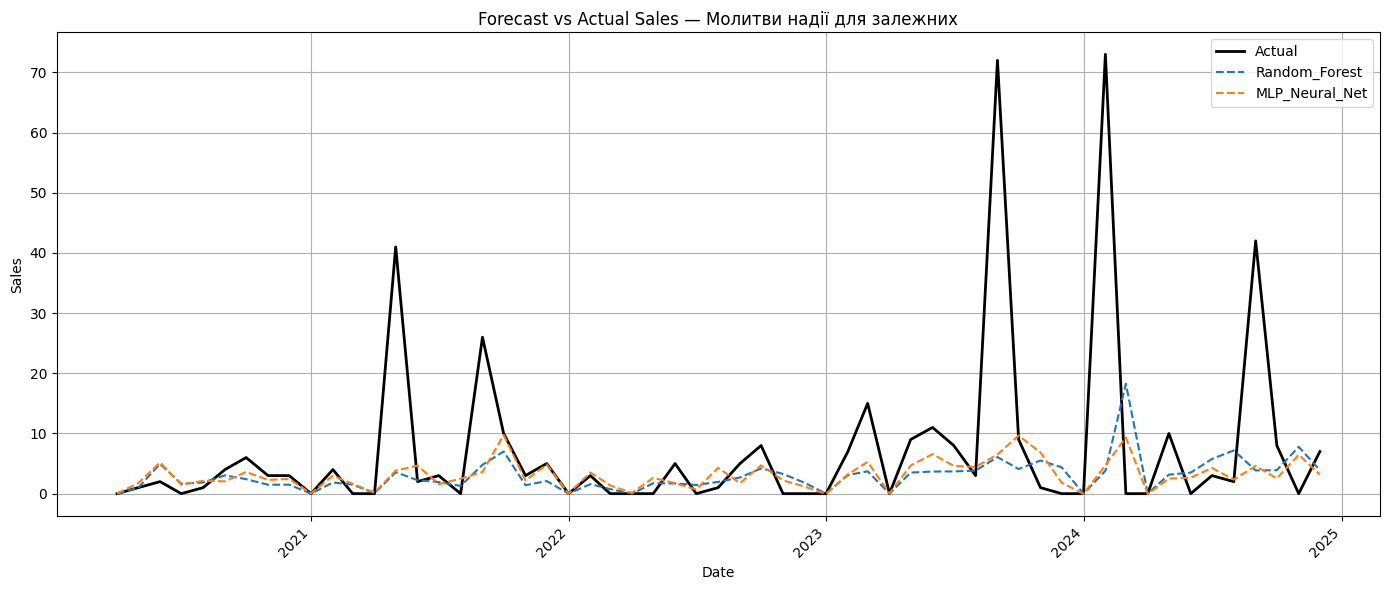

In [14]:
book_counts = predictions_df['Title'].value_counts()
all_titles = book_counts.index.tolist()
# define median for selecting books from the middle of predictions dataset
median = len(all_titles) // 2
selected_books = all_titles[max(0, median-1):median+2]

plot_forecasts_per_book(
    predictions_df,
    book_ids=selected_books,
    models_to_show=["Random_Forest", 'MLP_Neural_Net']
)